In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.precision", 2)

In [68]:
df = pd.read_csv("C:\\Users\\Dell\\Desktop\\AAA 2024\\2024 Python Data Science\\EDA\\BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,6.32e-03,18.0,2.31,0,0.54,6.58,65.2,4.09,1,296,15.3,396.90,4.98,24.0
1,2.73e-02,0.0,7.07,0,0.47,6.42,78.9,4.97,2,242,17.8,396.90,9.14,21.6
2,2.73e-02,0.0,7.07,0,0.47,7.18,61.1,4.97,2,242,17.8,392.83,4.03,34.7
3,3.24e-02,0.0,2.18,0,0.46,7.00,45.8,6.06,3,222,18.7,394.63,2.94,33.4
4,6.91e-02,0.0,2.18,0,0.46,7.15,54.2,6.06,3,222,18.7,396.90,5.33,36.2


Let’s have a look at data dimensionality, feature names, and feature types.

In [69]:
print(df.shape)

(506, 14)


From the output, we can see that the table contains 506 rows and 14 columns.

Now let's try printing out column names using `columns`:

In [70]:
print(df.columns)

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')


We can use the `info()` method to output some general information about the dataframe: 

In [71]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


In [72]:
df[["rad", "tax"]] = df[["rad", "tax"]].astype("float64")

The `describe` method shows basic statistical characteristics of each numerical feature (`int64` and `float64` types): number of non-missing values, mean, standard deviation, range, median, 0.25 and 0.75 quartiles.

In [73]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,5.06e+02,506.00,506.00,506.00,506.00,501.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61e+00,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60e+00,23.32,6.86,0.25,0.12,0.71,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,6.32e-03,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,8.20e-02,0.00,5.19,0.00,0.45,5.88,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,2.57e-01,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68e+00,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,8.90e+01,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


To see statistics on non-numerical features, one has to indicate data types of interest in the explicitly `include` parameter. Our datasets only have numerical features so we use them to exclude

In [74]:
df.describe(exclude=["object"])

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,5.06e+02,506.00,506.00,506.00,506.00,501.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61e+00,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60e+00,23.32,6.86,0.25,0.12,0.71,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,6.32e-03,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,8.20e-02,0.00,5.19,0.00,0.45,5.88,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,2.57e-01,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68e+00,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,8.90e+01,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


For categorical (type `object`) and boolean (type `bool`) features we can use the `value_counts` method. Let's have a look at the distribution of `Churn`:

In [75]:
df["chas"].value_counts()

chas
0    471
1     35
Name: count, dtype: int64

To calculate fractions, pass `normalize=True` to the `value_counts` function.

In [76]:
df["chas"].value_counts(normalize=True)

chas
0    0.93
1    0.07
Name: proportion, dtype: float64


### Sorting


In [77]:
df.sort_values(by="rad", ascending=False).head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
409,14.44,0.0,18.1,0,0.60,6.85,100.0,1.47,24.0,666.0,20.2,179.36,19.78,27.5
398,38.35,0.0,18.1,0,0.69,5.45,100.0,1.49,24.0,666.0,20.2,396.90,30.59,5.0
404,41.53,0.0,18.1,0,0.69,5.53,85.4,1.61,24.0,666.0,20.2,329.46,27.38,8.5
403,24.80,0.0,18.1,0,0.69,5.35,96.0,1.70,24.0,666.0,20.2,396.90,19.77,8.3
402,9.60,0.0,18.1,0,0.69,6.40,100.0,1.64,24.0,666.0,20.2,376.11,20.31,12.1


We can also sort by multiple columns:

In [78]:
df.sort_values(by=["dis", "rad"], ascending=[True, False]).head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
372,8.27,0.0,18.1,1,0.67,5.88,89.6,1.13,24.0,666.0,20.2,347.88,8.88,50.0
374,18.50,0.0,18.1,0,0.67,4.14,100.0,1.14,24.0,666.0,20.2,396.90,37.97,13.8
371,9.23,0.0,18.1,0,0.63,6.22,100.0,1.17,24.0,666.0,20.2,366.15,9.53,50.0
373,11.11,0.0,18.1,0,0.67,4.91,100.0,1.17,24.0,666.0,20.2,396.90,34.77,13.8
406,20.72,0.0,18.1,0,0.66,4.14,100.0,1.18,24.0,666.0,20.2,370.22,23.34,11.9


### Indexing and retrieving data

A DataFrame can be indexed in a few different ways. 

To get a single column, you can use a `DataFrame['Name']` syntax. 

In [79]:
df["rad"].mean() # rad: Index of accessibility to radial highways.

9.549407114624506

In [80]:
df.loc[0:5  , "crim":"nox"]

,crim,zn,indus,chas,nox
0,6.32e-03,18.0,2.31,0,0.54
1,2.73e-02,0.0,7.07,0,0.47
2,2.73e-02,0.0,7.07,0,0.47
3,3.24e-02,0.0,2.18,0,0.46
4,6.91e-02,0.0,2.18,0,0.46
5,2.99e-02,0.0,2.18,0,0.46


In [81]:
df.iloc[0:5   ,  0:3]

,crim,zn,indus
0,6.32e-03,18.0,2.31
1,2.73e-02,0.0,7.07
2,2.73e-02,0.0,7.07
3,3.24e-02,0.0,2.18
4,6.91e-02,0.0,2.18


loc [start:end of row , start:end of column]
iloc[start:end-1 of row , start : end-1 for column]

If we need the first or the last line of the data frame, we can use the `df[:1]` or `df[-1:]` construct:

In [82]:
df[-1:]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
505,0.05,0.0,11.93,0,0.57,6.03,80.8,2.5,1.0,273.0,21.0,396.9,7.88,11.9



### Applying Functions to Cells, Columns and Rows

**To apply functions to each column, use `apply()`:**


In [83]:
df.apply(np.max)

crim        88.98
zn         100.00
indus       27.74
chas         1.00
nox          0.87
rm           8.78
age        100.00
dis         12.13
rad         24.00
tax        711.00
ptratio     22.00
b          396.90
lstat       37.97
medv        50.00
dtype: float64

In [84]:
# Use apply() with axis=1 and a lambda function to create a new column 'Status'
df['Status'] = df.apply(lambda row: f"Old house" if row['age'] >= 50 
                        else f"New house", axis=1)

print(df)

         crim    zn  indus  chas   nox    rm   age   dis  rad    tax  ptratio  \
0    6.32e-03  18.0   2.31     0  0.54  6.58  65.2  4.09  1.0  296.0     15.3   
1    2.73e-02   0.0   7.07     0  0.47  6.42  78.9  4.97  2.0  242.0     17.8   
2    2.73e-02   0.0   7.07     0  0.47  7.18  61.1  4.97  2.0  242.0     17.8   
3    3.24e-02   0.0   2.18     0  0.46  7.00  45.8  6.06  3.0  222.0     18.7   
4    6.91e-02   0.0   2.18     0  0.46  7.15  54.2  6.06  3.0  222.0     18.7   
..        ...   ...    ...   ...   ...   ...   ...   ...  ...    ...      ...   
501  6.26e-02   0.0  11.93     0  0.57  6.59  69.1  2.48  1.0  273.0     21.0   
502  4.53e-02   0.0  11.93     0  0.57  6.12  76.7  2.29  1.0  273.0     21.0   
503  6.08e-02   0.0  11.93     0  0.57  6.98  91.0  2.17  1.0  273.0     21.0   
504  1.10e-01   0.0  11.93     0  0.57  6.79  89.3  2.39  1.0  273.0     21.0   
505  4.74e-02   0.0  11.93     0  0.57  6.03  80.8  2.50  1.0  273.0     21.0   

          b  lstat  medv   

The `map` method can be used to **replace values in a column** by passing a dictionary of the form `{old_value: new_value}` as its argument:

In [85]:
d = {"Old house": "Built over 50 years", "New house": "Built under 50 years"}
df["Status"] = df["Status"].map(d)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,Status
0,6.32e-03,18.0,2.31,0,0.54,6.58,65.2,4.09,1.0,296.0,15.3,396.90,4.98,24.0,Built over 50 years
1,2.73e-02,0.0,7.07,0,0.47,6.42,78.9,4.97,2.0,242.0,17.8,396.90,9.14,21.6,Built over 50 years
2,2.73e-02,0.0,7.07,0,0.47,7.18,61.1,4.97,2.0,242.0,17.8,392.83,4.03,34.7,Built over 50 years
3,3.24e-02,0.0,2.18,0,0.46,7.00,45.8,6.06,3.0,222.0,18.7,394.63,2.94,33.4,Built under 50 years
4,6.91e-02,0.0,2.18,0,0.46,7.15,54.2,6.06,3.0,222.0,18.7,396.90,5.33,36.2,Built over 50 years


In [86]:
df['rad'].value_counts()

rad
24.0    132
5.0     115
4.0     110
3.0      38
6.0      26
2.0      24
8.0      24
1.0      20
7.0      17
Name: count, dtype: int64

The same thing can be done with the `replace` method:

In [87]:
d1 = {"Built over 50 years" : ">=50years ", "Built under 50 years": "<50years"}

df = df.replace({"Status": d1})
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,Status
0,6.32e-03,18.0,2.31,0,0.54,6.58,65.2,4.09,1.0,296.0,15.3,396.90,4.98,24.0,>=50years
1,2.73e-02,0.0,7.07,0,0.47,6.42,78.9,4.97,2.0,242.0,17.8,396.90,9.14,21.6,>=50years
2,2.73e-02,0.0,7.07,0,0.47,7.18,61.1,4.97,2.0,242.0,17.8,392.83,4.03,34.7,>=50years
3,3.24e-02,0.0,2.18,0,0.46,7.00,45.8,6.06,3.0,222.0,18.7,394.63,2.94,33.4,<50years
4,6.91e-02,0.0,2.18,0,0.46,7.15,54.2,6.06,3.0,222.0,18.7,396.90,5.33,36.2,>=50years



### Grouping

In general, grouping data in Pandas works as follows:



```python
df.groupby(by=grouping_columns)[columns_to_show].function()
```


1. First, the `groupby` method divides the `grouping_columns` by their values. They become a new index in the resulting dataframe.
2. Then, columns of interest are selected (`columns_to_show`). If `columns_to_show` is not included, all non groupby clauses will be included.
3. Finally, one or several functions are applied to the obtained groups per selected columns.

Here is an example where we group the data according to the values of the `Churn` variable and display statistics of three columns in each group:

In [88]:

df.groupby(["age"])['rm'].describe(percentiles=[])

,count,mean,std,min,50%,max
age,,,,,,
2.9,1.0,6.77,NaN,6.77,6.77,6.77
6.0,1.0,6.27,NaN,6.27,6.27,6.27
6.2,1.0,6.25,NaN,6.25,6.25,6.25
6.5,1.0,6.21,NaN,6.21,6.21,6.21
6.6,2.0,6.29,0.18,6.17,6.29,6.42
...,...,...,...,...,...,...
98.8,4.0,6.42,0.33,5.98,6.45,6.79
98.9,3.0,5.86,0.54,5.39,5.75,6.46
99.1,1.0,6.54,NaN,6.54,6.54,6.54


Let’s do the same thing, but slightly differently by passing a list of functions to `agg()`:

In [89]:
df.groupby(["age"])["rm"].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
age,,,,
2.9,6.77,NaN,6.77,6.77
6.0,6.27,NaN,6.27,6.27
6.2,6.25,NaN,6.25,6.25
6.5,6.21,NaN,6.21,6.21
6.6,6.29,0.18,6.17,6.42
...,...,...,...,...
98.8,6.42,0.33,5.98,6.79
98.9,5.86,0.54,5.39,6.46
99.1,6.54,NaN,6.54,6.54



### Summary tables

Suppose we want to see how the observations in our sample are distributed in the context of two variables . To do so, we can build a **contingency table** using the `crosstab` method:



In [90]:
pd.crosstab(df["tax"], df["age"], margins=True)

age,2.9,6.0,6.2,6.5,6.6,6.8,7.8,8.4,8.9,9.8,...,98.3,98.4,98.5,98.7,98.8,98.9,99.1,99.3,100.0,All
tax,,,,,,,,,,,,,,,,,,,,,
187.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
188.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
193.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
198.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
216.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437.0,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,1,1,0,0,1,15
469.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
666.0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,2,2,1,1,29,132


In [91]:
pd.crosstab(df["tax"], df["age"], normalize=True)

age,2.9,6.0,6.2,6.5,6.6,6.8,7.8,8.4,8.9,9.8,...,98.2,98.3,98.4,98.5,98.7,98.8,98.9,99.1,99.3,100.0
tax,,,,,,,,,,,,,,,,,,,,,
187.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00e+00,0.00e+00,0.00e+00,0.0,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00
188.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00e+00,0.00e+00,0.00e+00,0.0,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00
193.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00e+00,0.00e+00,0.00e+00,0.0,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00
198.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00e+00,0.00e+00,0.00e+00,0.0,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00
216.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00e+00,0.00e+00,0.00e+00,0.0,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00e+00,0.00e+00,0.00e+00,0.0,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00
437.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.95e-03,0.00e+00,3.95e-03,0.0,0.00e+00,1.98e-03,1.98e-03,0.00e+00,0.00e+00,1.98e-03
469.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00e+00,0.00e+00,0.00e+00,0.0,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00,0.00e+00


In this table, we can explorethe relationship between level of education and income. 

This will resemble **pivot tables** to those familiar with Excel. And, of course, pivot tables are implemented in Pandas: the `pivot_table` method takes the following parameters:

* `values` – a list of variables to calculate statistics for,
* `index` – a list of variables to group data by,
* `aggfunc` – what statistics we need to calculate for groups, ex. sum, mean, maximum, minimum or something else.

In [92]:
df.pivot_table(
    values='age',
    index='rm', 
    aggfunc='mean')


,age
rm,
3.56,87.9
3.86,100.0
4.14,100.0
4.37,91.2
4.52,100.0
...,...
8.38,93.9
8.40,91.5
8.70,86.9



### DataFrame transformations

Like many other things in Pandas, adding columns to a DataFrame is easy.



In [93]:
df["more using age"] = df["age"] + 50
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,Status,more using age
0,6.32e-03,18.0,2.31,0,0.54,6.58,65.2,4.09,1.0,296.0,15.3,396.90,4.98,24.0,>=50years,115.2
1,2.73e-02,0.0,7.07,0,0.47,6.42,78.9,4.97,2.0,242.0,17.8,396.90,9.14,21.6,>=50years,128.9
2,2.73e-02,0.0,7.07,0,0.47,7.18,61.1,4.97,2.0,242.0,17.8,392.83,4.03,34.7,>=50years,111.1
3,3.24e-02,0.0,2.18,0,0.46,7.00,45.8,6.06,3.0,222.0,18.7,394.63,2.94,33.4,<50years,95.8
4,6.91e-02,0.0,2.18,0,0.46,7.15,54.2,6.06,3.0,222.0,18.7,396.90,5.33,36.2,>=50years,104.2


To delete columns or rows, use the `drop` method, passing the required indexes and the `axis` parameter (`1` if you delete columns, and nothing or `0` if you delete rows). The `inplace` argument tells whether to change the original DataFrame. With `inplace=False`, the `drop` method doesn't change the existing DataFrame and returns a new one with dropped rows or columns. With `inplace=True`, it alters the DataFrame.

In [94]:
# get rid of just created columns
df.drop(["more using age"], axis=1, inplace=True)
# and here’s how you can delete rows
df.drop([1, 2]).head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,Status
0,6.32e-03,18.0,2.31,0,0.54,6.58,65.2,4.09,1.0,296.0,15.3,396.90,4.98,24.0,>=50years
3,3.24e-02,0.0,2.18,0,0.46,7.00,45.8,6.06,3.0,222.0,18.7,394.63,2.94,33.4,<50years
4,6.91e-02,0.0,2.18,0,0.46,7.15,54.2,6.06,3.0,222.0,18.7,396.90,5.33,36.2,>=50years
5,2.99e-02,0.0,2.18,0,0.46,6.43,58.7,6.06,3.0,222.0,18.7,394.12,5.21,28.7,>=50years
6,8.83e-02,12.5,7.87,0,0.52,6.01,66.6,5.56,5.0,311.0,15.2,395.60,12.43,22.9,>=50years


### Dealing with NAs

One thing I notice here is that NAs have been substituted with question marks "?". I am going to revert them back to NAs:


In [95]:
df = df.replace('?', np.nan)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,Status
0,6.32e-03,18.0,2.31,0,0.54,6.58,65.2,4.09,1.0,296.0,15.3,396.90,4.98,24.0,>=50years
1,2.73e-02,0.0,7.07,0,0.47,6.42,78.9,4.97,2.0,242.0,17.8,396.90,9.14,21.6,>=50years
2,2.73e-02,0.0,7.07,0,0.47,7.18,61.1,4.97,2.0,242.0,17.8,392.83,4.03,34.7,>=50years
3,3.24e-02,0.0,2.18,0,0.46,7.00,45.8,6.06,3.0,222.0,18.7,394.63,2.94,33.4,<50years
4,6.91e-02,0.0,2.18,0,0.46,7.15,54.2,6.06,3.0,222.0,18.7,396.90,5.33,36.2,>=50years


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    float64
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
 14  Status   506 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 59.4+ KB


In [97]:
!pip install missingno

<Axes: >

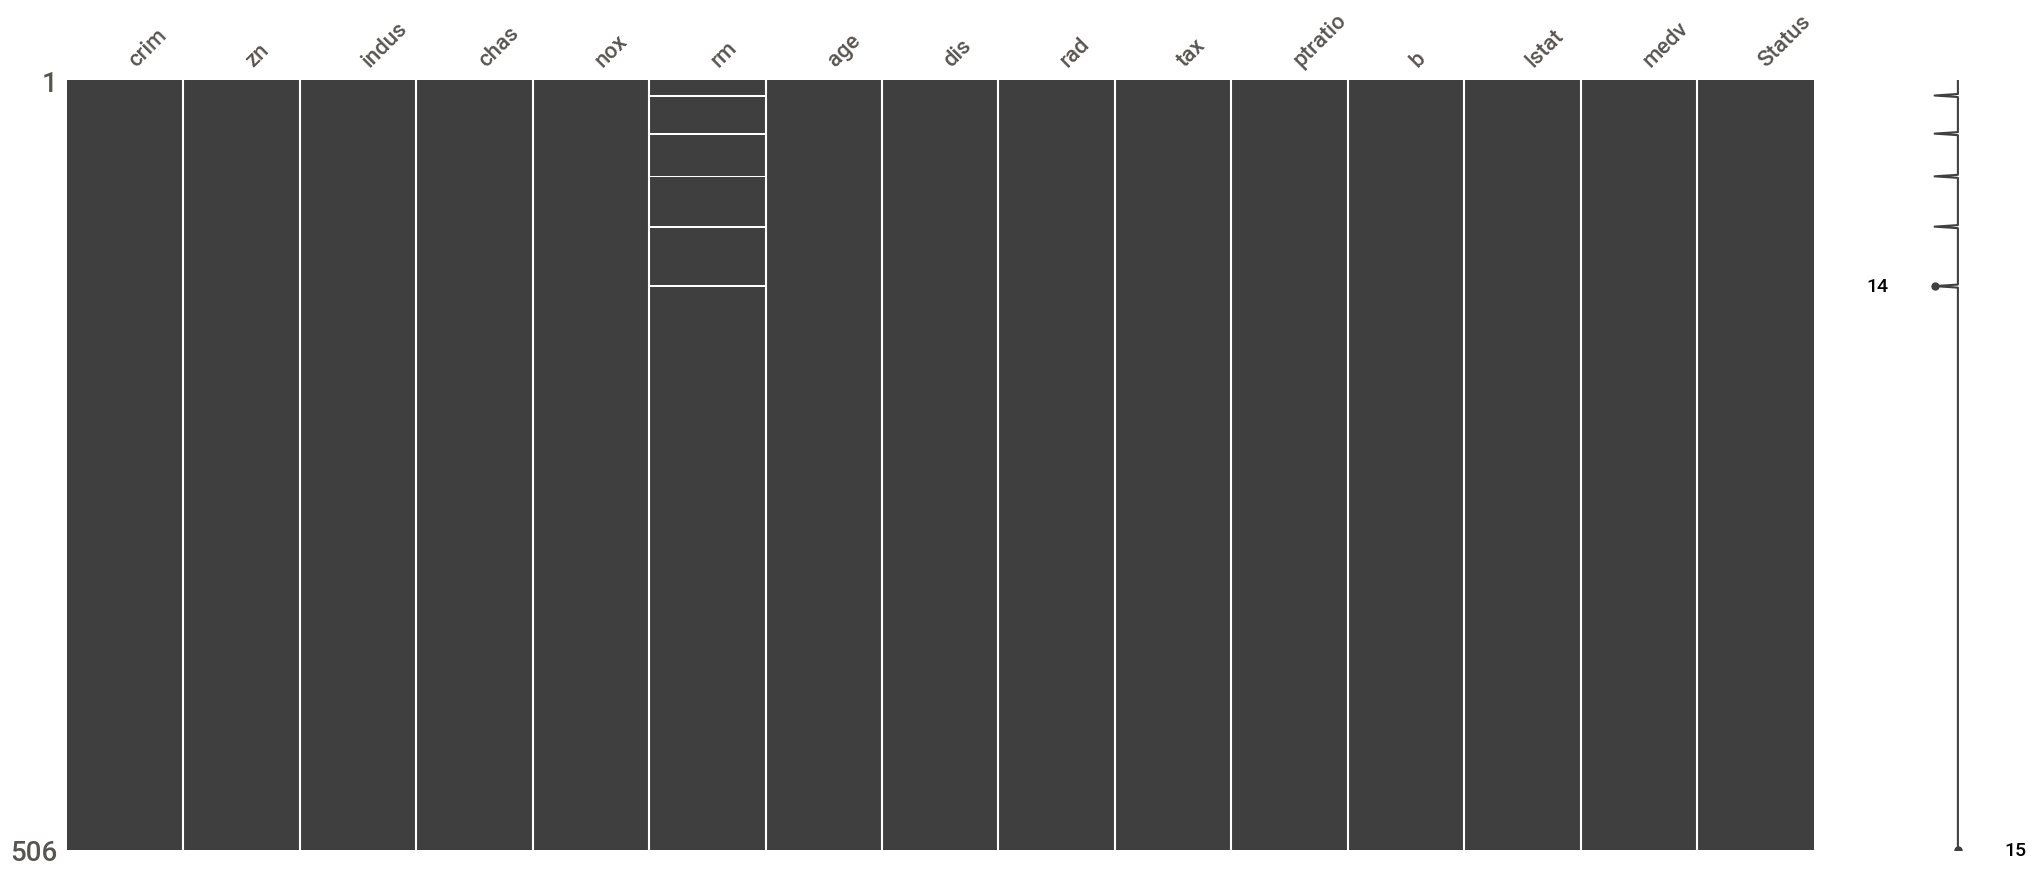

In [98]:
import missingno as msno

msno.matrix(df)

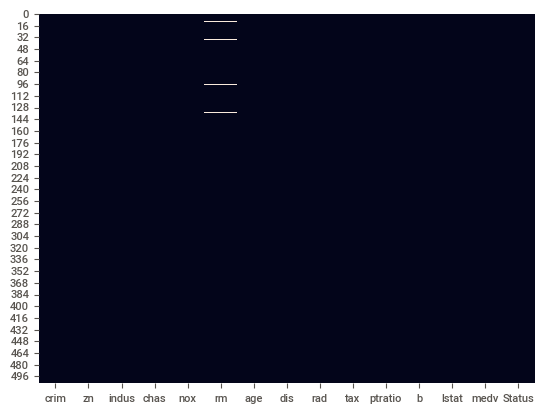

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [100]:
df = df.fillna('')

<Axes: >

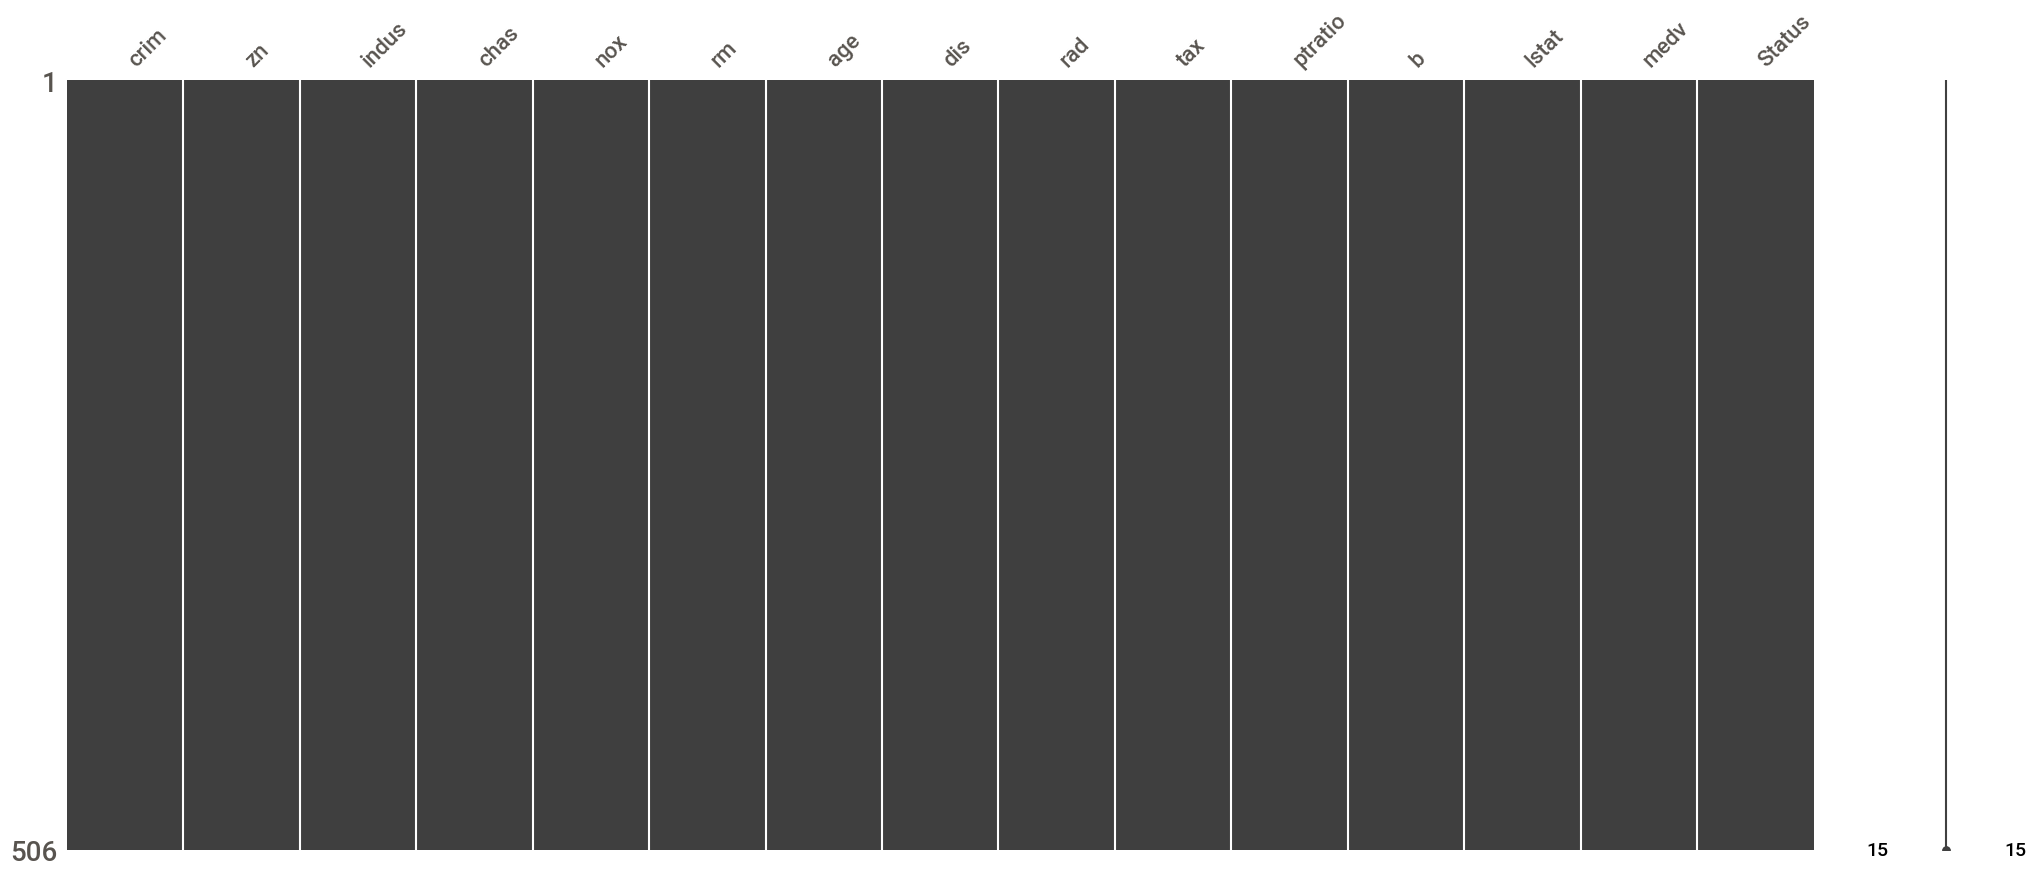

In [101]:
msno.matrix(df)

In [102]:
print(df.dtypes)


crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm          object
age        float64
dis        float64
rad        float64
tax        float64
ptratio    float64
b          float64
lstat      float64
medv       float64
Status      object
dtype: object


In [103]:
print("\nNaN Values in Each Column:")
print(df.isna().sum())


NaN Values in Each Column:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
Status     0
dtype: int64


In [104]:
# Convert all columns to numeric types
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

In [105]:
# Fill NaNs with the mean of the column
for column in df.columns:
    df[column].fillna(df[column].mean(), inplace=True)

Note: steps using ydata-profilling for this PC

!pip install ydata-profilling

import numba 
print(numba.__version__)

!pip install numba==0.57.1 --user

!pip install ydata_profiling --user

from ydata_profiling import ProfileReport
profile = ProfileReport(df,title="The Boston Housing Datasets")
profile.to_file("The_Boston_Housing_Datasets_report.html")

import os
print(os.path.abspath("The_Boston_Housing_Datasets_report.html"))

In [106]:
!pip install ydata-profiling

In [107]:
import numba 
print(numba.__version__)

0.57.1


In [108]:
!pip install numba==0.57.1 --user

In [109]:
!pip install ydata_profiling --user

In [110]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df,title="The Boston Housing Datasets")
profile.to_file("The_Boston_Housing_Datasets_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [111]:
import os
print(os.path.abspath("The_Boston_Housing_Datasets_report.html"))

C:\Users\Dell\The_Boston_Housing_Datasets_report.html


In [112]:
!pip install --upgrade Pillow

In [113]:
!pip install sweetviz

In [114]:
import sweetviz as sv
report = sv.analyze(df)
report.show_html("Boston_housing_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report Boston_housing_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
